#  Will Buy EV 


## 1. Setup & Config

In [ ]:
!pip install lightgbm
!pip install catboost
!pip install xgboost

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 23.0 MB/s  0:00:00


In [11]:
!pip install kaggle


   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   -------------------------- ------------- 

SyntaxError: invalid syntax (1815505810.py, line 1)

In [20]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb

import kaggle

SEED = 42
FOLDS = 5
TARGET = 'Will_Buy_EV'

DATA_DIR = '/kaggle/input/competitions/playground-series-s6e9'
EXTERNAL_PATH = 'EV_Adoption_and_Range_Anxiety_Dataset.csv'

np.random.seed(SEED)
pd.set_option('display.max_columns', 50)


## 2. Load Data

Target is mapped to 0/1  — everything downstream (plots, feature engineering, models) assumes a numeric target. 

In [21]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
extern_data = pd.read_csv(EXTERNAL_PATH)

train_df[TARGET] = train_df[TARGET].map({'Yes': 1, 'No': 0}).astype(int)
# External dataset's target may already be 0/1 or Yes/No depending on source formatting — handle both.
extern_data[TARGET] = extern_data[TARGET].replace({'Yes': 1, 'No': 0}).astype(int)

print(f"Train:    {train_df.shape}")
print(f"Test:     {test_df.shape}")
print(f"External: {extern_data.shape}")

overall_conv = train_df[TARGET].mean() * 100
print(f"\nBaseline conversion rate (train): {overall_conv:.2f}%")


Train:    (668665, 15)
Test:     (286571, 14)
External: (10000, 15)

Baseline conversion rate (train): 17.46%


## 3. Data Quality Check

In [22]:
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()
print("Missing values — train:")
print(missing_train[missing_train > 0] if missing_train.sum() else "  none")
print("\nMissing values — test:")
print(missing_test[missing_test > 0] if missing_test.sum() else "  none")

print("\nTarget distribution:")
display(train_df[TARGET].value_counts(normalize=True).rename('proportion').to_frame())


Missing values — train:
  none

Missing values — test:
  none

Target distribution:


,proportion
Will_Buy_EV,
0,0.825355
1,0.174645


## 4. EDA — Conversion Rate by Category

One function instead of two near-duplicate plotting blocks.

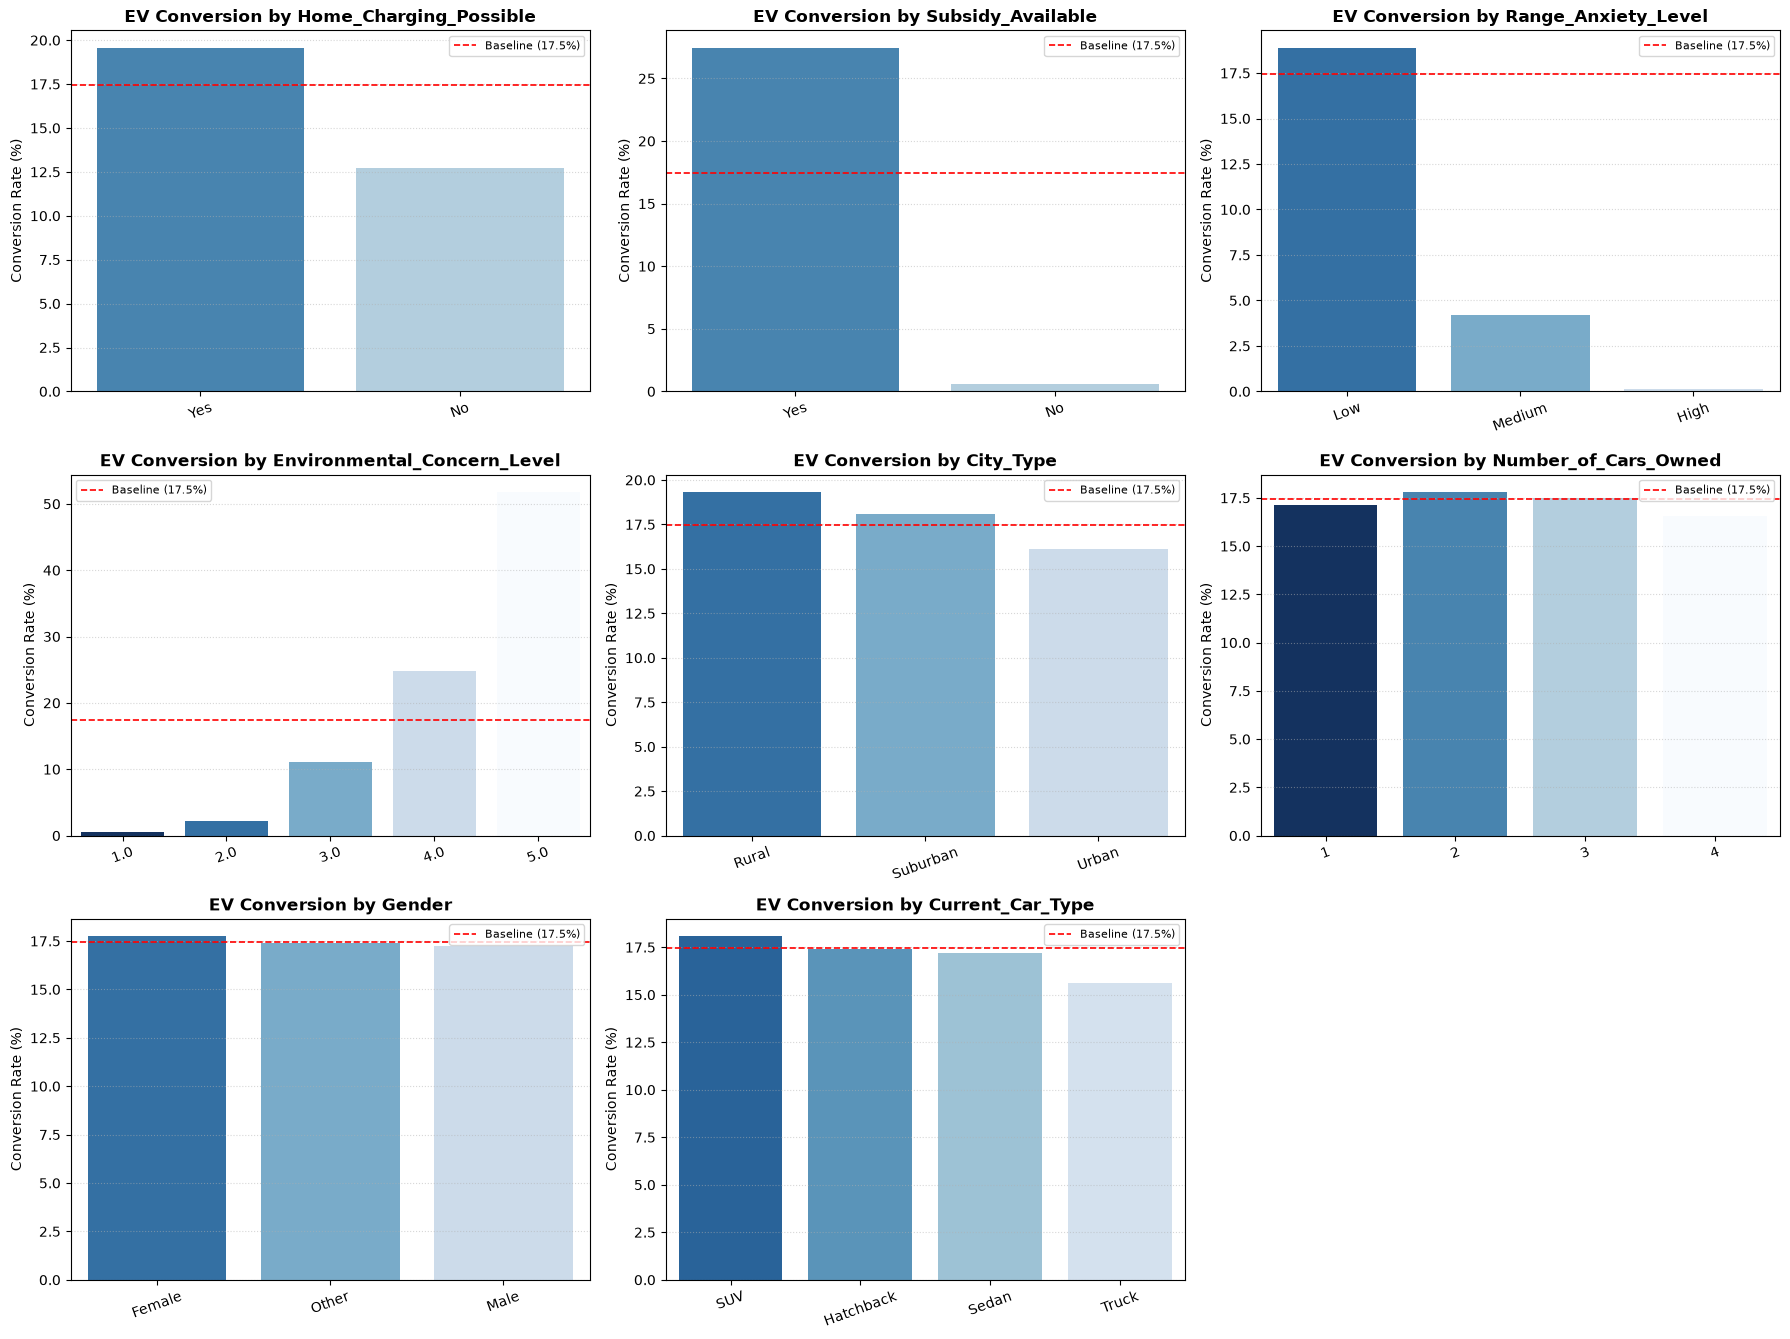

In [23]:
def plot_conversion_by_category(df, cols, target, baseline, ncols=3, palette='Blues_r'):
    nrows = -(-len(cols) // ncols)  # ceil
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for i, col in enumerate(cols):
        stats = df.groupby(col, observed=True)[target].agg(Total='count', Conversion_Rate=lambda x: x.mean() * 100).reset_index()
        stats = stats.sort_values('Conversion_Rate', ascending=False)
        sns.barplot(data=stats, x=col, y='Conversion_Rate', hue=col, legend=False, ax=axes[i], palette=palette)
        axes[i].axhline(baseline, color='red', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline:.1f}%)')
        axes[i].set_title(f'EV Conversion by {col}', fontweight='bold')
        axes[i].set_ylabel('Conversion Rate (%)')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)
        axes[i].legend(fontsize=8)
        axes[i].grid(axis='y', linestyle=':', alpha=0.5)
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

categorical_cols = ['Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level',
                     'Environmental_Concern_Level', 'City_Type', 'Number_of_Cars_Owned',
                     'Gender', 'Current_Car_Type']
plot_conversion_by_category(train_df, categorical_cols, TARGET, overall_conv)


## 5. EDA — Continuous Features

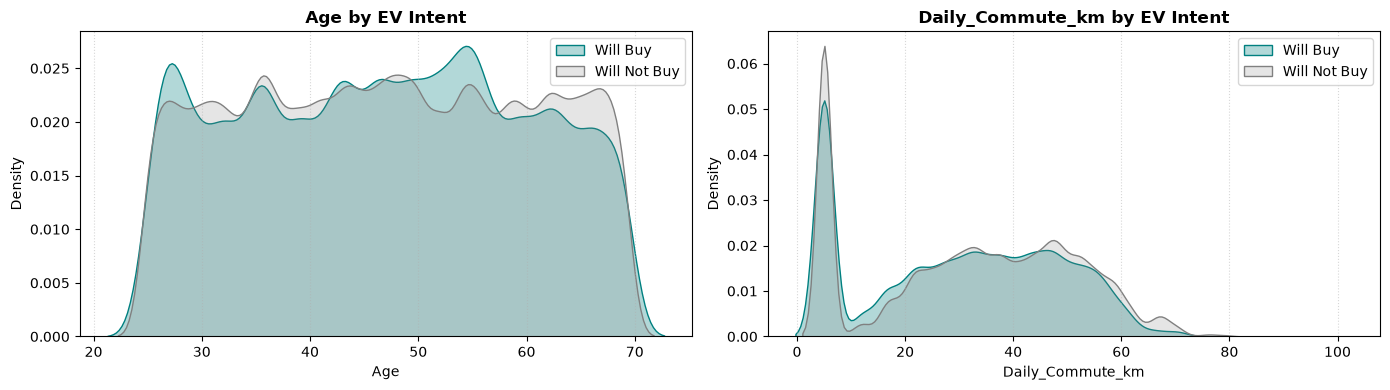

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(['Age', 'Daily_Commute_km']):
    sns.kdeplot(data=train_df[train_df[TARGET] == 1], x=col, label='Will Buy', ax=axes[i], fill=True, alpha=0.3, color='teal')
    sns.kdeplot(data=train_df[train_df[TARGET] == 0], x=col, label='Will Not Buy', ax=axes[i], fill=True, alpha=0.2, color='gray')
    axes[i].set_title(f'{col} by EV Intent', fontweight='bold')
    axes[i].legend()
    axes[i].grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


##  Income "Dead Zone" 


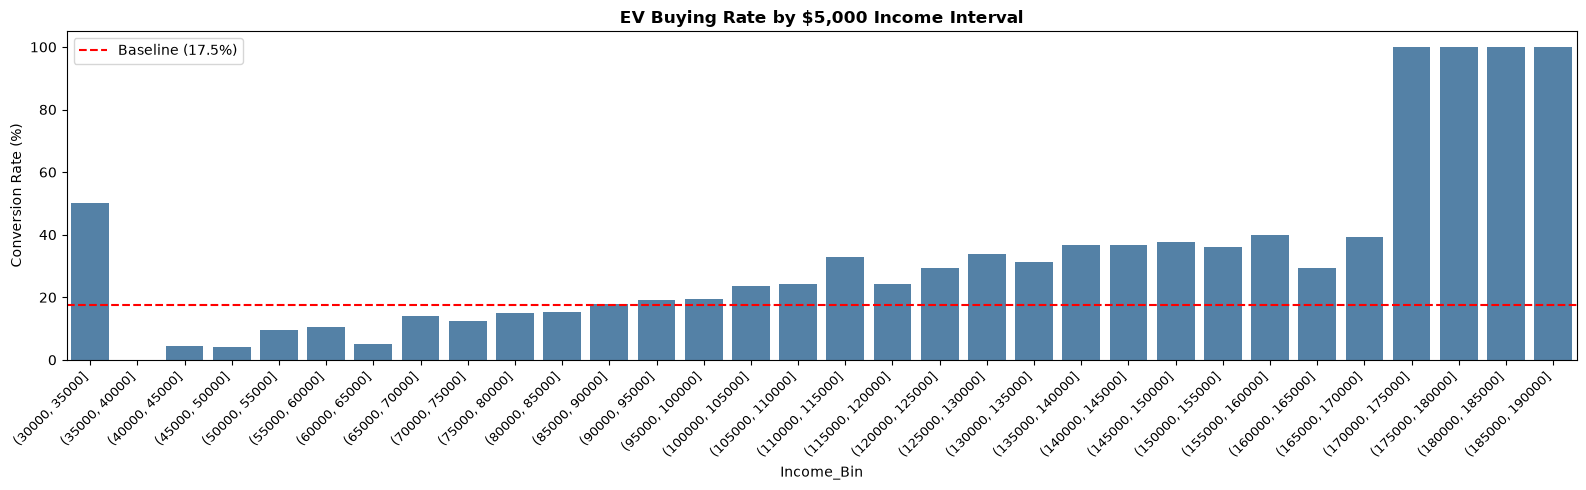

Income $38k-$42k 'dead zone': 1,277 respondents, 2 buyers, 0.157% conversion (vs 17.46% baseline)

'Ideal adopter' segment: 69,398 respondents (10.38%), 72.51% conversion


In [25]:
income_bins = np.arange(30000, 195000, 5000)
train_df['Income_Bin'] = pd.cut(train_df['Annual_Income_USD'], bins=income_bins)
income_stats = train_df.groupby('Income_Bin', observed=False)[TARGET].agg(
    Respondents='count', EV_Buyers='sum', Conversion_Rate=lambda x: x.mean() * 100
).reset_index()

plt.figure(figsize=(16, 5))
sns.barplot(data=income_stats, x='Income_Bin', y='Conversion_Rate', color='steelblue')
plt.axhline(overall_conv, color='red', linestyle='--', label=f'Baseline ({overall_conv:.1f}%)')
plt.title('EV Buying Rate by $5,000 Income Interval', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

train_df.drop(columns=['Income_Bin'], inplace=True)

dead_zone = train_df[(train_df['Annual_Income_USD'] >= 38000) & (train_df['Annual_Income_USD'] <= 42000)]
print(f"Income $38k-$42k 'dead zone': {len(dead_zone):,} respondents, "
      f"{dead_zone[TARGET].sum()} buyers, {dead_zone[TARGET].mean()*100:.3f}% conversion "
      f"(vs {overall_conv:.2f}% baseline)")

ideal_filter = ((train_df['Subsidy_Available'] == 'Yes') & (train_df['Home_Charging_Possible'] == 'Yes') &
                 (train_df['Range_Anxiety_Level'] == 'Low') & (train_df['Environmental_Concern_Level'] == 5))
ideal_segment = train_df[ideal_filter]
print(f"\n'Ideal adopter' segment: {len(ideal_segment):,} respondents "
      f"({len(ideal_segment)/len(train_df):.2%}), {ideal_segment[TARGET].mean()*100:.2f}% conversion")


**Fold-safety check** — recompute these two rates on the *training* portion of every CV fold. If the numbers barely move across folds, the rule is real signal

In [26]:
_skf_check = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
dead_zone_flag = ((train_df['Annual_Income_USD'] >= 38000) & (train_df['Annual_Income_USD'] <= 42000))
ideal_flag = ideal_filter

for name, flag in [('Dead zone (38k-42k)', dead_zone_flag), ('Ideal adopter profile', ideal_flag)]:
    rates = []
    for tr_idx, _ in _skf_check.split(train_df, train_df[TARGET]):
        sub_target = train_df[TARGET].iloc[tr_idx]
        sub_flag = flag.iloc[tr_idx]
        rates.append(sub_target[sub_flag].mean() * 100)
    print(f"{name}: per-fold conversion rate = {[round(r, 2) for r in rates]}  "
          f"(range: {max(rates)-min(rates):.2f} pts)")


Dead zone (38k-42k): per-fold conversion rate = [np.float64(0.0), np.float64(0.2), np.float64(0.19), np.float64(0.2), np.float64(0.19)]  (range: 0.20 pts)
Ideal adopter profile: per-fold conversion rate = [np.float64(72.58), np.float64(72.6), np.float64(72.39), np.float64(72.53), np.float64(72.45)]  (range: 0.21 pts)


Both rules are essentially identical across every fold . That's strong evidence these are deterministic rules the synthetic generator actually uses, not something fit to noise, and they should generalize to the leaderboard the same way they generalize across folds.

## 7. External Dataset — Audit & Cleaning

In [27]:
ext_conv = extern_data[TARGET].mean() * 100
ext_dead_zone = extern_data[(extern_data['Annual_Income_USD'] >= 38000) & (extern_data['Annual_Income_USD'] <= 42000)]
ext_dead_conv = ext_dead_zone[TARGET].mean() * 100 if len(ext_dead_zone) else float('nan')

print(f"External dataset conversion rate: {ext_conv:.2f}% (competition train: {overall_conv:.2f}%)")
print(f"External 'dead zone' conversion:  {ext_dead_conv:.2f}% over {len(ext_dead_zone)} rows")
print("If this is > 0%, the dead zone is specific to how this competition's synthetic labels were generated,")
print("not a property of real-world EV-buying behavior — worth knowing before you lean on it too hard conceptually.")

ext_nulls = extern_data.isnull().sum()
print("\nMissing values in external data:")
print(ext_nulls[ext_nulls > 0] if ext_nulls.sum() else "  none")


External dataset conversion rate: 17.50% (competition train: 17.46%)
External 'dead zone' conversion:  10.31% over 223 rows
If this is > 0%, the dead zone is specific to how this competition's synthetic labels were generated,
not a property of real-world EV-buying behavior — worth knowing before you lean on it too hard conceptually.

Missing values in external data:
Annual_Income_USD              178
Daily_Commute_km               181
Environmental_Concern_Level    184
dtype: int64


In [28]:
for col, fill in [('Annual_Income_USD', train_df['Annual_Income_USD'].median()),
                  ('Daily_Commute_km', train_df['Daily_Commute_km'].median()),
                  ('Environmental_Concern_Level', train_df['Environmental_Concern_Level'].mode()[0])]:
    if col in extern_data.columns:
        extern_data[col] = extern_data[col].fillna(fill)

print("External data cleaned. Remaining missing values:")
remaining = extern_data.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() else "  none")


External data cleaned. Remaining missing values:
  none


## 8. Feature Engineering

In [29]:
def engineer_features(df):
    data = df.copy()

    data['is_dead_zone'] = ((data['Annual_Income_USD'] >= 38000.0) & (data['Annual_Income_USD'] <= 42000.0)).astype(int)
    data['Total_Charging_Access'] = data['Charging_Stations_Near_Home'] + data['Charging_Stations_Near_Work']
    data['Commute_Income_Ratio'] = (data['Daily_Commute_km'] / (data['Annual_Income_USD'] + 1)) * 1000
    data['Short_Commute_Sweetspot'] = ((data['Daily_Commute_km'] >= 4.0) & (data['Daily_Commute_km'] <= 12.0)).astype(int)
    data['Subsidized_High_Income'] = ((data['Subsidy_Available'] == 'Yes') & (data['Annual_Income_USD'] >= 84880.0)).astype(int)
    data['High_Anxiety_Long_Commute'] = ((data['Range_Anxiety_Level'] == 'High') & (data['Daily_Commute_km'] > 45.0)).astype(int)
    data['Ideal_Adopter_Profile'] = (
        (data['Subsidy_Available'] == 'Yes') &
        (data['Home_Charging_Possible'] == 'Yes') &
        (data['Range_Anxiety_Level'] == 'Low') &
        (data['Environmental_Concern_Level'] == 5)
    ).astype(int)

    return data

train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)
extern_fe = engineer_features(extern_data)

print("Feature-engineered shapes:", train_fe.shape, test_fe.shape, extern_fe.shape)


Feature-engineered shapes: (668665, 22) (286571, 21) (10000, 22)


## Merge External Data Into Training


In [31]:
USE_EXTERNAL_DATA = True  # <-- flip to True to test, then compare OOF AUC against the baseline run

if USE_EXTERNAL_DATA:
    shared_cols = [c for c in train_fe.columns if c in extern_fe.columns]
    train_for_model = pd.concat([train_fe[shared_cols], extern_fe[shared_cols]], ignore_index=True)
    print(f"Merged training data: {train_fe.shape[0]:,} + {extern_fe.shape[0]:,} = {train_for_model.shape[0]:,} rows")
else:
    train_for_model = train_fe
    print(f"Using competition training data only: {train_for_model.shape[0]:,} rows")


Merged training data: 668,665 + 10,000 = 678,665 rows


## 10. Prepare Modeling Features

Explicit feature lists . 

In [32]:
CATEGORICAL_FEATURES = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
                         'Subsidy_Available', 'Range_Anxiety_Level']
NUMERIC_FEATURES = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
                     'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level',
                     'is_dead_zone', 'Total_Charging_Access', 'Commute_Income_Ratio', 'Short_Commute_Sweetspot',
                     'Subsidized_High_Income', 'High_Anxiety_Long_Commute', 'Ideal_Adopter_Profile']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for col in CATEGORICAL_FEATURES:
    train_for_model[col] = train_for_model[col].astype('category')
    test_fe[col] = test_fe[col].astype('category')

X = train_for_model[FEATURES]
y = train_for_model[TARGET]
X_test = test_fe[FEATURES]

print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical = {len(FEATURES)} features")


14 numeric + 6 categorical = 20 features


## 11. Cross-Validation Harness

One function used by all three models instead of three copy-pasted ~30-line loops. It also records **train AUC from the actual fitted fold model** 

In [33]:
def run_cv(build_model, X, y, X_test, folds, seed, label, fit_kwargs_fn=None):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_val_scores, fold_train_scores = [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        model = build_model()
        fit_kwargs = fit_kwargs_fn(X_va, y_va) if fit_kwargs_fn else {}
        model.fit(X_tr, y_tr, **fit_kwargs)

        tr_pred = model.predict_proba(X_tr)[:, 1]
        va_pred = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = va_pred
        test_pred += model.predict_proba(X_test)[:, 1] / folds

        tr_auc = roc_auc_score(y_tr, tr_pred)
        va_auc = roc_auc_score(y_va, va_pred)
        fold_train_scores.append(tr_auc)
        fold_val_scores.append(va_auc)
        print(f"[{label}] Fold {fold}: train AUC={tr_auc:.5f}  val AUC={va_auc:.5f}  gap={tr_auc-va_auc:.5f}")

    oof_auc = roc_auc_score(y, oof)
    print(f"[{label}] OOF AUC={oof_auc:.5f} | mean train AUC={np.mean(fold_train_scores):.5f} "
          f"| mean gap={np.mean(fold_train_scores) - np.mean(fold_val_scores):.5f}\n")
    return oof, test_pred, fold_val_scores, fold_train_scores


## 12. Train LightGBM

In [34]:
def build_lgbm():
    return lgb.LGBMClassifier(
        objective='binary', metric='auc', n_estimators=2000, learning_rate=0.03,
        num_leaves=63, min_child_samples=50, reg_alpha=0.1, reg_lambda=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbose=-1
    )

lgbm_oof, lgbm_test, lgbm_val_scores, lgbm_train_scores = run_cv(
    build_lgbm, X, y, X_test, FOLDS, SEED, 'LightGBM',
    fit_kwargs_fn=lambda Xv, yv: dict(eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(100, verbose=False)])
)


d:\program\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] Fold 1: train AUC=0.94676  val AUC=0.94192  gap=0.00484


d:\program\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] Fold 2: train AUC=0.94730  val AUC=0.94105  gap=0.00625


d:\program\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] Fold 3: train AUC=0.94675  val AUC=0.94116  gap=0.00559


d:\program\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] Fold 4: train AUC=0.94724  val AUC=0.94142  gap=0.00582


d:\program\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] Fold 5: train AUC=0.94866  val AUC=0.93987  gap=0.00879
[LightGBM] OOF AUC=0.94107 | mean train AUC=0.94734 | mean gap=0.00626



## 13. Train CatBoost

In [41]:
def build_cb():
    return CatBoostClassifier(
        iterations=2000, learning_rate=0.03, eval_metric='AUC',
        cat_features=CATEGORICAL_FEATURES, l2_leaf_reg=5.0,
        max_ctr_complexity=1,      # <-- disables expensive categorical feature crosses
        thread_count=-1,           # explicit: use all CPU cores
        random_seed=SEED, verbose=200   # <-- prints progress every 200 iters so you can see it's alive
    )



In [42]:
cb_oof, cb_test, cb_val_scores, cb_train_scores = run_cv(
    build_cb, X, y, X_test, FOLDS, SEED, 'CatBoost',
    fit_kwargs_fn=lambda Xv, yv: dict(eval_set=(Xv, yv), early_stopping_rounds=100)
)

0:	test: 0.9288261	best: 0.9288261 (0)	total: 136ms	remaining: 4m 30s
200:	test: 0.9400262	best: 0.9400262 (200)	total: 25.2s	remaining: 3m 45s
400:	test: 0.9407678	best: 0.9407678 (400)	total: 51s	remaining: 3m 23s
600:	test: 0.9411978	best: 0.9411978 (600)	total: 1m 17s	remaining: 2m 59s
800:	test: 0.9415166	best: 0.9415166 (800)	total: 1m 47s	remaining: 2m 40s
1000:	test: 0.9417217	best: 0.9417217 (1000)	total: 2m 15s	remaining: 2m 14s
1200:	test: 0.9418482	best: 0.9418482 (1200)	total: 2m 42s	remaining: 1m 48s
1400:	test: 0.9419400	best: 0.9419400 (1400)	total: 3m 10s	remaining: 1m 21s
1600:	test: 0.9420047	best: 0.9420050 (1599)	total: 3m 38s	remaining: 54.5s
1800:	test: 0.9420387	best: 0.9420387 (1799)	total: 4m 6s	remaining: 27.2s
1999:	test: 0.9420709	best: 0.9420711 (1972)	total: 4m 34s	remaining: 0us

bestTest = 0.942071132
bestIteration = 1972

Shrink model to first 1973 iterations.
[CatBoost] Fold 1: train AUC=0.94316  val AUC=0.94207  gap=0.00109
0:	test: 0.9279810	best: 0

## 14. Train XGBoost


In [38]:
def build_xgb():
    return xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.03, max_depth=6, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', enable_categorical=True, eval_metric='auc',
        early_stopping_rounds=100, random_state=SEED, n_jobs=-1
    )

xgb_oof, xgb_test, xgb_val_scores, xgb_train_scores = run_cv(
    build_xgb, X, y, X_test, FOLDS, SEED, 'XGBoost',
    fit_kwargs_fn=lambda Xv, yv: dict(eval_set=[(Xv, yv)], verbose=False)
)


[XGBoost] Fold 1: train AUC=0.94486  val AUC=0.94193  gap=0.00293
[XGBoost] Fold 2: train AUC=0.94546  val AUC=0.94115  gap=0.00430
[XGBoost] Fold 3: train AUC=0.94549  val AUC=0.94124  gap=0.00425
[XGBoost] Fold 4: train AUC=0.94605  val AUC=0.94155  gap=0.00451
[XGBoost] Fold 5: train AUC=0.94612  val AUC=0.93987  gap=0.00624
[XGBoost] OOF AUC=0.94114 | mean train AUC=0.94560 | mean gap=0.00445



## 15. Overfitting Diagnostic — On The Actual Models

This replaces the original diagnostic cell, which measured a disconnected `n_estimators=100`, non-early-stopped model that has nothing to do with the models actually trained above.

In [43]:
summary = pd.DataFrame({
    'Model': ['LightGBM', 'CatBoost', 'XGBoost'],
    'Mean Train AUC': [np.mean(lgbm_train_scores), np.mean(cb_train_scores), np.mean(xgb_train_scores)],
    'Mean Val AUC':   [np.mean(lgbm_val_scores),   np.mean(cb_val_scores),   np.mean(xgb_val_scores)],
})
summary['Train-Val Gap'] = summary['Mean Train AUC'] - summary['Mean Val AUC']
summary['Fold Val Std'] = [np.std(lgbm_val_scores), np.std(cb_val_scores), np.std(xgb_val_scores)]
display(summary)

print("\nRule of thumb for GBMs on tabular data: a train-val AUC gap under ~0.01-0.02 with early stopping,")
print("plus low fold-to-fold variance, is a healthy fit — not overfitting. A gap that's large *and* fold scores")
print("that swing wildly between folds is the actual overfitting signature to watch for.")


,Model,Mean Train AUC,Mean Val AUC,Train-Val Gap,Fold Val Std
0,LightGBM,0.947343,0.941085,0.006259,0.000677
1,CatBoost,0.943198,0.941106,0.002092,0.000782
2,XGBoost,0.945597,0.941151,0.004447,0.000694



Rule of thumb for GBMs on tabular data: a train-val AUC gap under ~0.01-0.02 with early stopping,
plus low fold-to-fold variance, is a healthy fit — not overfitting. A gap that's large *and* fold scores
that swing wildly between folds is the actual overfitting signature to watch for.


## 16. Blend Models

Simple OOF-optimized weighted average across the three models 

In [44]:
best_auc, best_weights = -1, (1, 0, 0)
for w1 in np.arange(0, 1.01, 0.05):
    for w2 in np.arange(0, 1.01 - w1, 0.05):
        w3 = 1 - w1 - w2
        blend_oof = w1 * lgbm_oof + w2 * cb_oof + w3 * xgb_oof
        auc = roc_auc_score(y, blend_oof)
        if auc > best_auc:
            best_auc, best_weights = auc, (w1, w2, w3)

print(f"Best blend weights (LightGBM, CatBoost, XGBoost) = {tuple(round(w, 2) for w in best_weights)}")
print(f"Blended OOF AUC = {best_auc:.5f}")
print(f"vs. LightGBM alone = {roc_auc_score(y, lgbm_oof):.5f}")
print(f"vs. CatBoost alone  = {roc_auc_score(y, cb_oof):.5f}")
print(f"vs. XGBoost alone   = {roc_auc_score(y, xgb_oof):.5f}")


Best blend weights (LightGBM, CatBoost, XGBoost) = (np.float64(0.35), np.float64(0.3), np.float64(0.35))
Blended OOF AUC = 0.94130
vs. LightGBM alone = 0.94107
vs. CatBoost alone  = 0.94110
vs. XGBoost alone   = 0.94114


## 17. Generate Submission

In [45]:
final_test_pred = best_weights[0] * lgbm_test + best_weights[1] * cb_test + best_weights[2] * xgb_test

submission = pd.DataFrame({'id': test_fe['id'], TARGET: final_test_pred})

print("Test prediction summary:")
print(f"  mean={submission[TARGET].mean():.4f}  min={submission[TARGET].min():.4f}  max={submission[TARGET].max():.4f}")

submission.to_csv('submission_blend.csv', index=False)
print("\nSaved submission_blend.csv")
display(submission.head(10))


Test prediction summary:
  mean=0.1751  min=0.0000  max=0.9681

Saved submission_blend.csv


,id,Will_Buy_EV
0,668665,0.010770
1,668666,0.023360
2,668667,0.005722
3,668668,0.003075
4,668669,0.022446
5,668670,0.004227
6,668671,0.371035
7,668672,0.000180
8,668673,0.652260
9,668674,0.005480
